In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image
from xpysom import XPySom    

cwd = Path.cwd().resolve()
if (cwd / "data").is_dir():
    ROOT = cwd
elif (cwd.parent / "data").is_dir():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not find data/ from {cwd}")

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

IMAGE_SIZE = (450, 450)
GRID_SIZES = [4, 8, 16]
NUM_ITERATIONS = 100
LEARNING_RATE = 0.5
RANDOM_SEED = 42

METRIC_FIELDS = [
    "image",
    "grid",
    "quantization_error",
    "mse",
    "psnr",
    "original_colors",
    "used_colors",
]

image_paths = sorted(
    path
    for path in DATA_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

print(f"{len(image_paths)} images from {DATA_DIR}")
for path in image_paths:
    print(path.name)
print(f"resize: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}")
print(f"grids: {', '.join(f'{grid}x{grid}' for grid in GRID_SIZES)}")
print(f"metrics: {RESULTS_DIR / 'metrics.csv'}")


In [2]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
    pixels = np.asarray(image)
    samples = pixels.reshape(-1, 3).astype(np.float32) / 255.0
    return image, pixels, samples


def train_som(samples, grid_size):
    som = XPySom(
        x=grid_size,
        y=grid_size,
        input_len=3,
        sigma=grid_size//2,
        learning_rate=LEARNING_RATE,
        random_seed=RANDOM_SEED,
    )
    som.train(samples, NUM_ITERATIONS, verbose=True)
    return som


def measure(som, samples, pixels):
    quantized = som.quantization(samples)
    quantized_image = np.clip(quantized, 0, 1).reshape(pixels.shape)
    palette = np.clip(som.get_weights(), 0, 1)

    mse = float(np.mean((samples - quantized) ** 2))
    psnr = float(10 * np.log10(1.0 / mse))
    quantization_error = float(som.quantization_error(samples))

    original_colors = int(len(np.unique(pixels.reshape(-1, 3), axis=0)))
    used = (np.clip(quantized, 0, 1) * 255).round().astype(np.uint8)
    used_colors = int(len(np.unique(used, axis=0)))

    return {
        "quantization_error": quantization_error,
        "mse": mse,
        "psnr": psnr,
        "original_colors": original_colors,
        "used_colors": used_colors,
        "quantized_image": quantized_image,
        "palette": palette,
    }


def save_metrics(metrics):
    metrics_path = RESULTS_DIR / "metrics.csv"
    with metrics_path.open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=METRIC_FIELDS)
        writer.writeheader()
        writer.writerows(metrics)
    return metrics_path


def load_metrics(path):
    with path.open(newline="") as file:
        rows = list(csv.DictReader(file))
    for row in rows:
        row["grid"] = int(row["grid"])
        row["quantization_error"] = float(row["quantization_error"])
        row["mse"] = float(row["mse"])
        row["psnr"] = float(row["psnr"])
        row["original_colors"] = int(row["original_colors"])
        row["used_colors"] = int(row["used_colors"])
    return rows


def show_image_results(image, stem, runs):
    n_cols = len(runs) + 1
    fig, axes = plt.subplots(
        2,
        n_cols,
        figsize=(3.5 * n_cols, 7.2),
        layout="constrained",
        gridspec_kw={"height_ratios": [1.35, 0.85]},
    )

    axes[0, 0].imshow(image)
    axes[0, 0].set_title(f"Original\n{runs[0]['original_colors']} colors")
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    for column, run in enumerate(runs, start=1):
        grid = run["grid"]
        axes[0, column].imshow(run["quantized_image"])
        axes[0, column].set_title(f"{grid}x{grid}\nPSNR {run['psnr']:.2f} dB")
        axes[0, column].axis("off")
        axes[1, column].imshow(run["palette"], interpolation="nearest")
        axes[1, column].set_title(f"Palette {grid}x{grid}\n{run['used_colors']} colors")
        axes[1, column].axis("off")

    fig.suptitle(stem, fontsize=14)
    figure_path = RESULTS_DIR / f"{stem}.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return figure_path


# Train SOM network




=== image1.jpg (450, 450) samples=(202500, 3) ===

training 4x4
 [ 20250000 / 20250000 ] 100% - 0:00:06 elapsed  - 0:00:00 left 
 quantization error: 0.06906008720397949
quantization error: 0.0691
MSE: 0.002453
PSNR: 26.10 dB
colors: 88207 -> 16

training 8x8
 [ 20250000 / 20250000 ] 100% - 0:00:17 elapsed  - 0:00:00 left 
 quantization error: 0.0348111130297184
quantization error: 0.0348
MSE: 0.000687
PSNR: 31.63 dB
colors: 88207 -> 64

training 16x16
 [ 20250000 / 20250000 ] 100% - 0:01:02 elapsed  - 0:00:00 left 
 quantization error: 0.019388776272535324
quantization error: 0.0194
MSE: 0.000219
PSNR: 36.59 dB
colors: 88207 -> 256


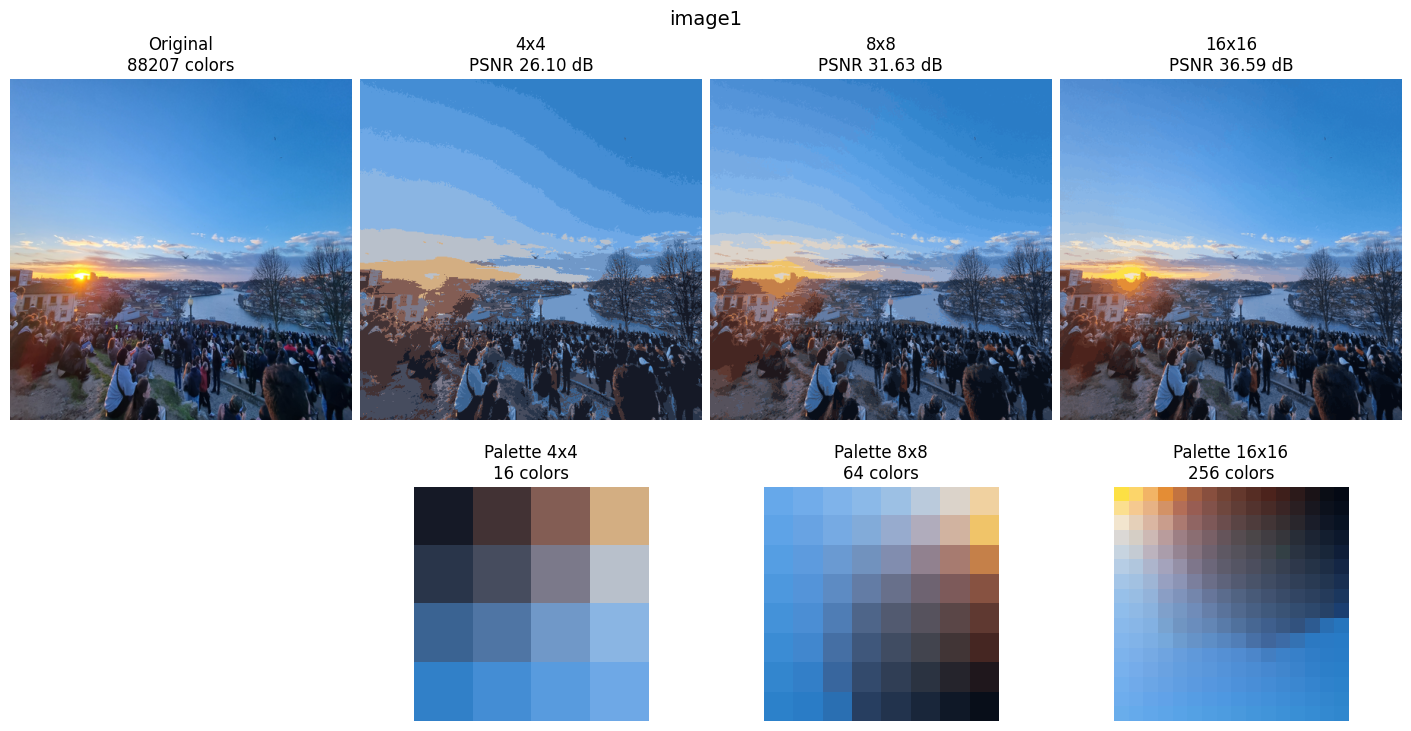

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/image1.png

=== image2.jpg (450, 450) samples=(202500, 3) ===

training 4x4
 [ 20250000 / 20250000 ] 100% - 0:00:06 elapsed  - 0:00:00 left 
 quantization error: 0.062020573765039444
quantization error: 0.0620
MSE: 0.001762
PSNR: 27.54 dB
colors: 81581 -> 16

training 8x8
 [ 20250000 / 20250000 ] 100% - 0:00:17 elapsed  - 0:00:00 left 
 quantization error: 0.032221026718616486
quantization error: 0.0322
MSE: 0.000506
PSNR: 32.96 dB
colors: 81581 -> 63

training 16x16
 [ 20250000 / 20250000 ] 100% - 0:01:02 elapsed  - 0:00:00 left 
 quantization error: 0.017460457980632782
quantization error: 0.0175
MSE: 0.000146
PSNR: 38.34 dB
colors: 81581 -> 254


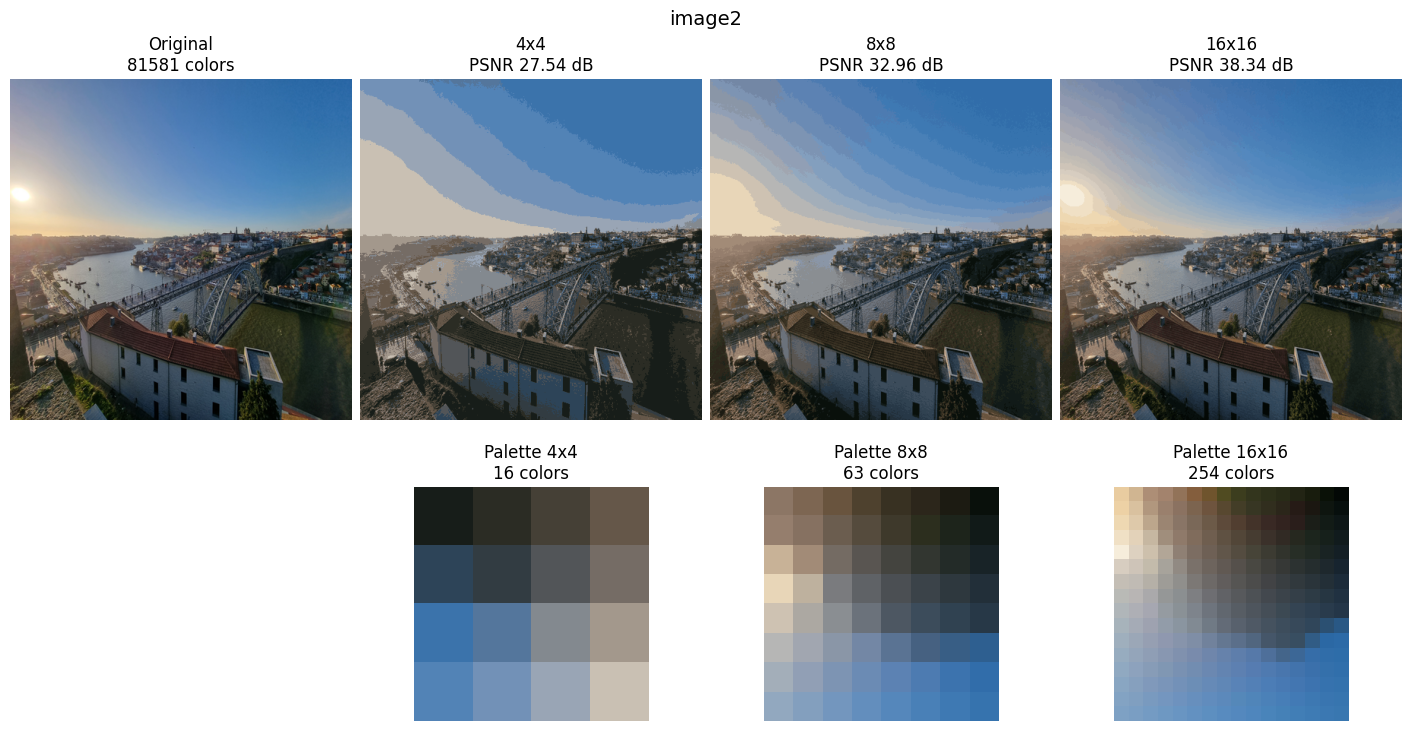

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/image2.png

=== image3.jpg (450, 450) samples=(202500, 3) ===

training 4x4
 [ 20250000 / 20250000 ] 100% - 0:00:05 elapsed  - 0:00:00 left 
 quantization error: 0.0590924434363842
quantization error: 0.0591
MSE: 0.001522
PSNR: 28.18 dB
colors: 73373 -> 16

training 8x8
 [ 20250000 / 20250000 ] 100% - 0:00:16 elapsed  - 0:00:00 left 
 quantization error: 0.02813369780778885
quantization error: 0.0281
MSE: 0.000377
PSNR: 34.24 dB
colors: 73373 -> 63

training 16x16
 [ 20250000 / 20250000 ] 100% - 0:01:03 elapsed  - 0:00:00 left 
 quantization error: 0.01519174873828888
quantization error: 0.0152
MSE: 0.000119
PSNR: 39.26 dB
colors: 73373 -> 250


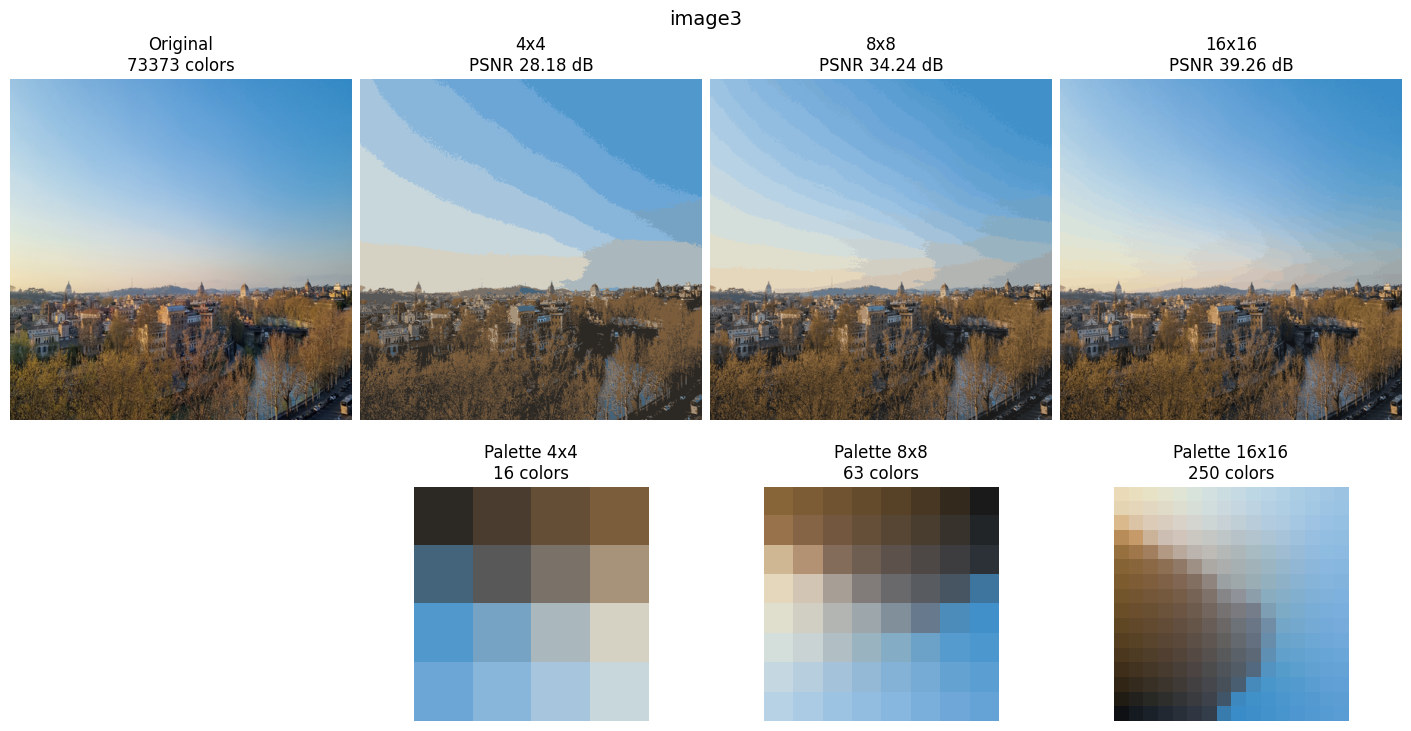

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/image3.png

=== image4.jpg (450, 450) samples=(202500, 3) ===

training 4x4
 [ 20250000 / 20250000 ] 100% - 0:00:06 elapsed  - 0:00:00 left 
 quantization error: 0.06655414402484894
quantization error: 0.0666
MSE: 0.002051
PSNR: 26.88 dB
colors: 88833 -> 16

training 8x8
 [ 20250000 / 20250000 ] 100% - 0:00:16 elapsed  - 0:00:00 left 
 quantization error: 0.03169765695929527
quantization error: 0.0317
MSE: 0.000552
PSNR: 32.58 dB
colors: 88833 -> 63

training 16x16
 [ 20250000 / 20250000 ] 100% - 0:01:03 elapsed  - 0:00:00 left 
 quantization error: 0.016911696642637253
quantization error: 0.0169
MSE: 0.000162
PSNR: 37.90 dB
colors: 88833 -> 254


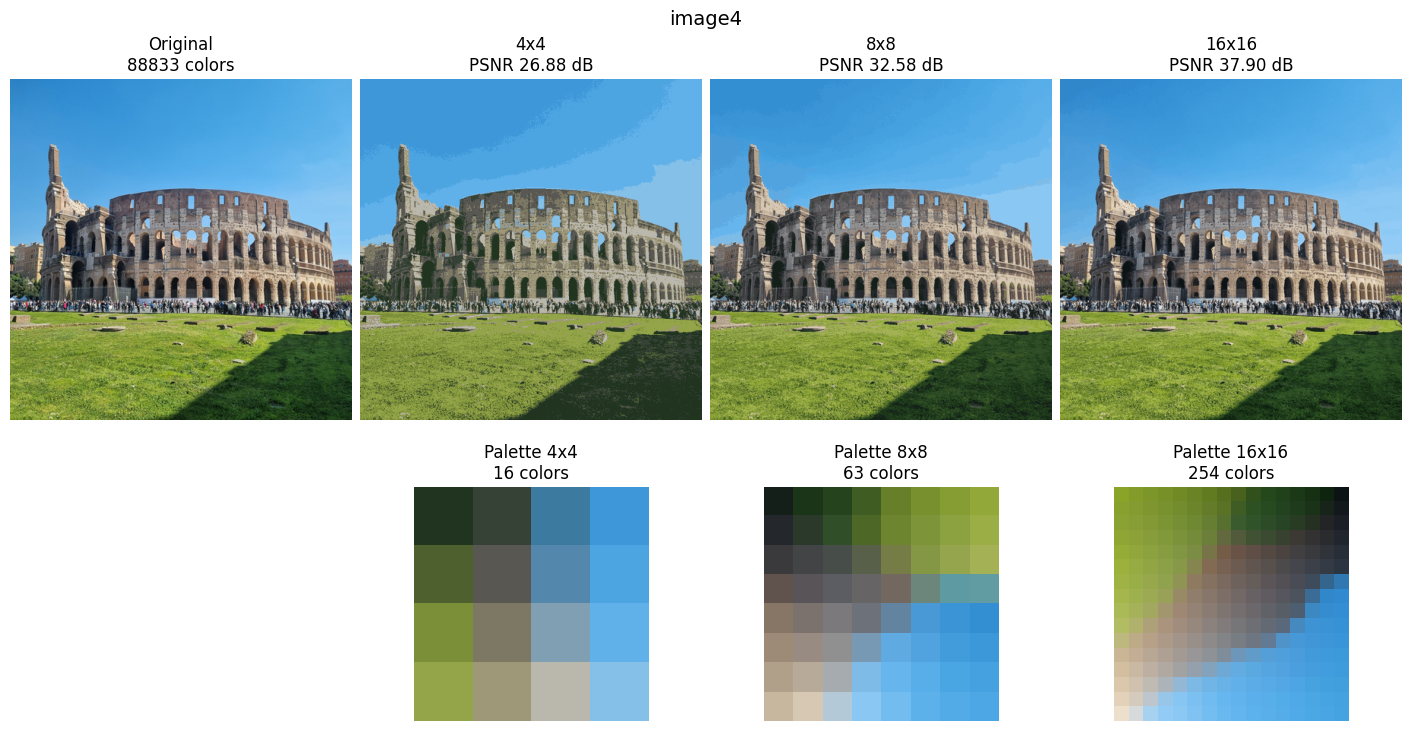

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/image4.png

=== image5.jpg (450, 450) samples=(202500, 3) ===

training 4x4
 [ 20250000 / 20250000 ] 100% - 0:00:06 elapsed  - 0:00:00 left 
 quantization error: 0.04435073956847191
quantization error: 0.0444
MSE: 0.001066
PSNR: 29.72 dB
colors: 55122 -> 16

training 8x8
 [ 20250000 / 20250000 ] 100% - 0:00:16 elapsed  - 0:00:00 left 
 quantization error: 0.02380582131445408
quantization error: 0.0238
MSE: 0.000352
PSNR: 34.53 dB
colors: 55122 -> 64

training 16x16
 [ 20250000 / 20250000 ] 100% - 0:01:03 elapsed  - 0:00:00 left 
 quantization error: 0.013240191154181957
quantization error: 0.0132
MSE: 0.000122
PSNR: 39.12 dB
colors: 55122 -> 256


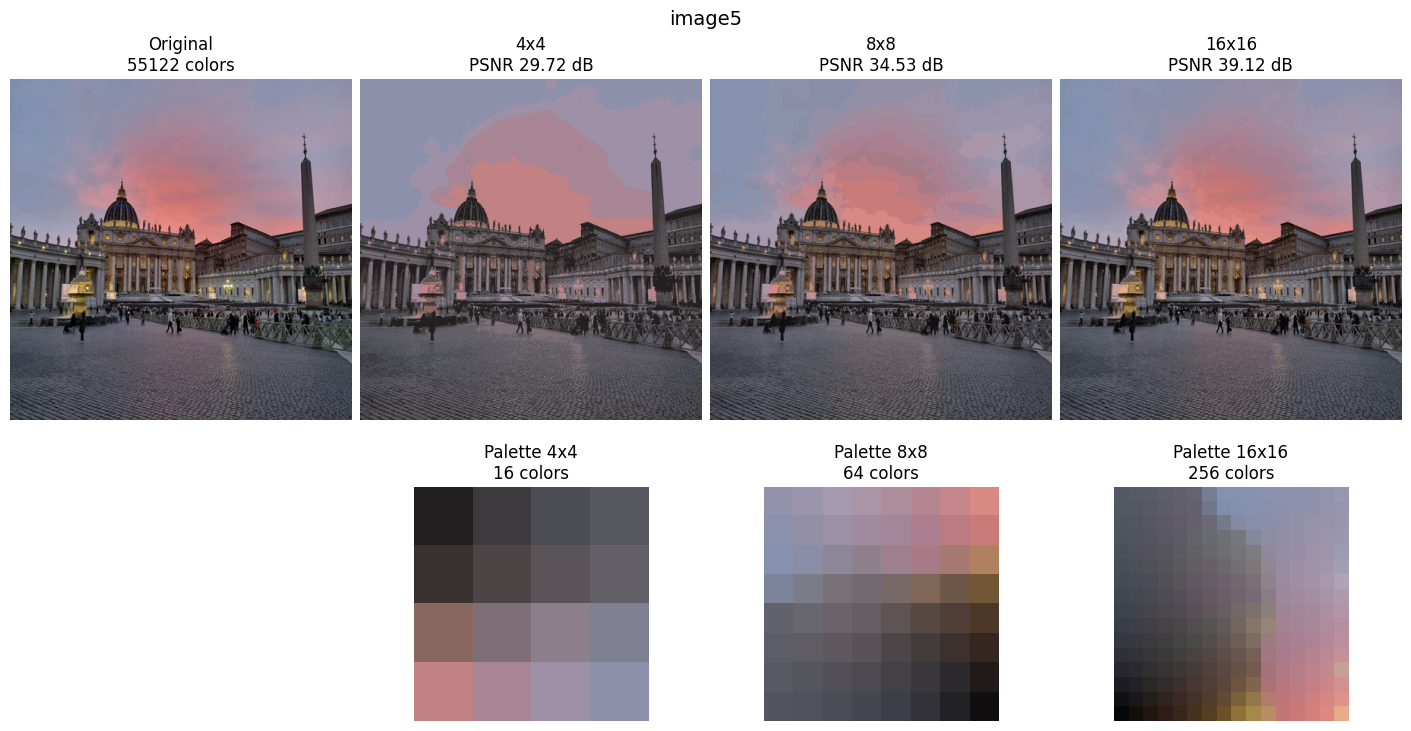

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/image5.png

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/metrics.csv (15 runs)


In [3]:
metrics = []

for image_path in image_paths:
    image, pixels, samples = load_image(image_path)
    print(f"\n=== {image_path.name} {image.size} samples={samples.shape} ===")
    image_runs = []

    for grid_size in GRID_SIZES:
        print(f"\ntraining {grid_size}x{grid_size}")
        som = train_som(samples, grid_size)
        result = measure(som, samples, pixels)

        record = {
            "image": image_path.stem,
            "grid": grid_size,
            "quantization_error": result["quantization_error"],
            "mse": result["mse"],
            "psnr": result["psnr"],
            "original_colors": result["original_colors"],
            "used_colors": result["used_colors"],
        }
        metrics.append(record)
        image_runs.append(result | {"grid": grid_size})
        save_metrics(metrics)

        print(f"quantization error: {record['quantization_error']:.4f}")
        print(f"MSE: {record['mse']:.6f}")
        print(f"PSNR: {record['psnr']:.2f} dB")
        print(f"colors: {record['original_colors']} -> {record['used_colors']}")

    figure_path = show_image_results(image, image_path.stem, image_runs)
    print(f"saved {figure_path}")

print(f"\nsaved {RESULTS_DIR / 'metrics.csv'} ({len(metrics)} runs)")


## Plotting the results comparison


image                    grid       QE        MSE     PSNR           colors
image1                  4x4    0.0691   0.002453    26.10  88207 -> 16   
image1                  8x8    0.0348   0.000687    31.63  88207 -> 64   
image1                 16x16   0.0194   0.000219    36.59  88207 -> 256  
image2                  4x4    0.0620   0.001762    27.54  81581 -> 16   
image2                  8x8    0.0322   0.000506    32.96  81581 -> 63   
image2                 16x16   0.0175   0.000146    38.34  81581 -> 254  
image3                  4x4    0.0591   0.001522    28.18  73373 -> 16   
image3                  8x8    0.0281   0.000377    34.24  73373 -> 63   
image3                 16x16   0.0152   0.000119    39.26  73373 -> 250  
image4                  4x4    0.0666   0.002051    26.88  88833 -> 16   
image4                  8x8    0.0317   0.000552    32.58  88833 -> 63   
image4                 16x16   0.0169   0.000162    37.90  88833 -> 254  
image5                  4x4    0.044

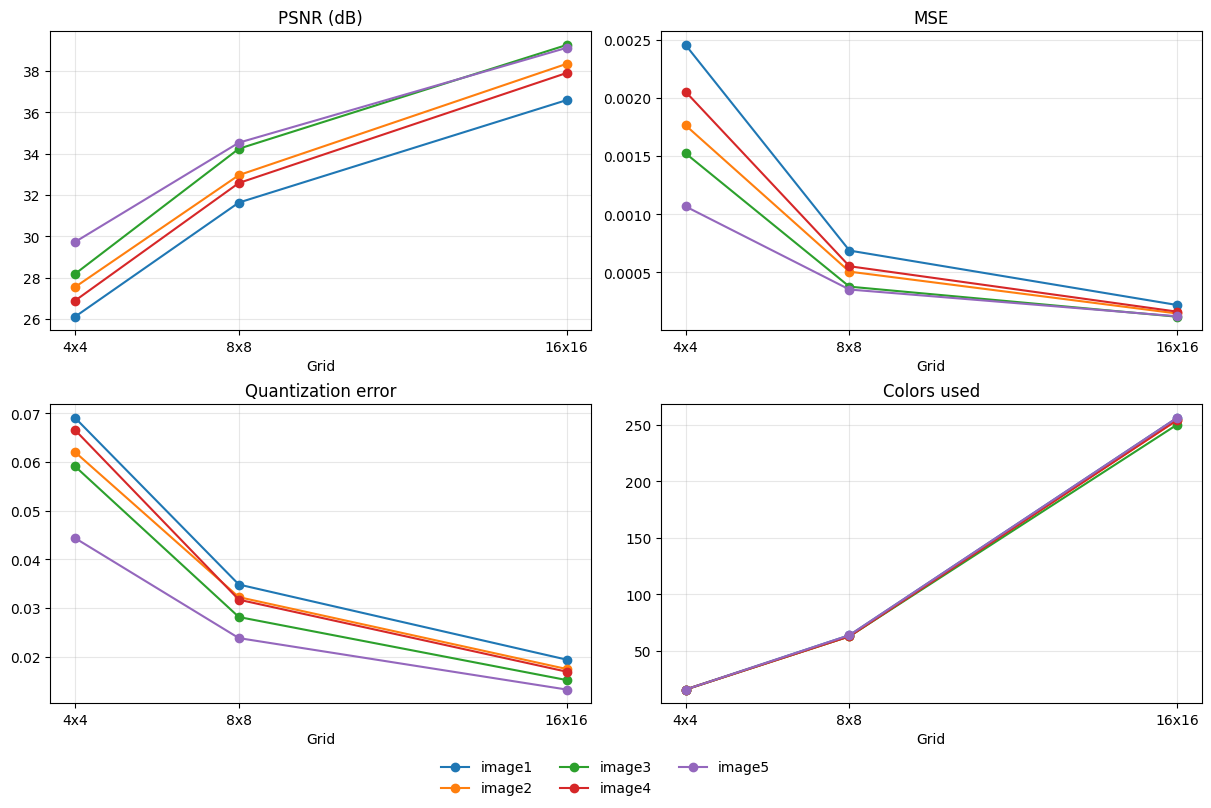

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/results/metrics_comparison.png


In [4]:
metrics_path = RESULTS_DIR / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError("Run the training cell first. metrics.csv was not found.")

loaded = load_metrics(metrics_path)
images = list(dict.fromkeys(row["image"] for row in loaded))

print(
    f"{'image':<22} {'grid':>6} {'QE':>8} {'MSE':>10} {'PSNR':>8} {'colors':>16}"
)
for row in loaded:
    print(
        f"{row['image']:<22} {row['grid']:>2}x{row['grid']:<2} "
        f"{row['quantization_error']:8.4f} {row['mse']:10.6f} {row['psnr']:8.2f} "
        f"{row['original_colors']:>6} -> {row['used_colors']:<5}"
    )

panels = [
    ("psnr", "PSNR (dB)"),
    ("mse", "MSE"),
    ("quantization_error", "Quantization error"),
    ("used_colors", "Colors used"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for ax, (key, title) in zip(axes.ravel(), panels):
    for name in images:
        rows = sorted(
            (row for row in loaded if row["image"] == name),
            key=lambda row: row["grid"],
        )
        ax.plot(
            [row["grid"] for row in rows],
            [row[key] for row in rows],
            marker="o",
            label=name,
        )
    ax.set_title(title)
    ax.set_xlabel("Grid")
    ax.set_xticks(GRID_SIZES)
    ax.set_xticklabels([f"{grid}x{grid}" for grid in GRID_SIZES])
    ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)

plot_path = RESULTS_DIR / "metrics_comparison.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"saved {plot_path}")
